# Lab 14 - Decoding Strategies from Scratch
## Greedy · Beam Search · Top-K · Top-P (Nucleus) · Temperature Sampling

> **Goal:** Build a tiny GPT, implement every major decoding strategy from scratch, and *visualise* how each one changes output diversity, probability distributions, and generation behaviour.

---
### What You'll Learn
| Strategy | Core Idea | Diversity |
|---|---|---|
| **Greedy** | Always pick the highest-prob token | ❌ None |
| **Beam Search** | Keep top-K partial sequences | 🔸 Low |
| **Top-K** | Sample from K most likely tokens | 🔶 Medium |
| **Top-P (Nucleus)** | Sample from smallest set covering P mass | 🔷 Adaptive |
| **Temperature** | Sharpen or flatten the distribution | 🔥 Tunable |


## 1 · Imports & Reproducibility

In [19]:
import math, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import Counter
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d2e",
    "axes.edgecolor": "#444", "axes.labelcolor": "#ddd",
    "xtick.color": "#aaa", "ytick.color": "#aaa",
    "text.color": "#eee", "grid.color": "#2a2d3e",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "monospace",
})
PALETTE = ["#7c3aed","#2563eb","#059669","#d97706","#dc2626","#db2777"]
print("Imports done - PyTorch", torch.__version__)


Imports done - PyTorch 2.11.0+cu128


## 2 · Tiny Vocabulary & Dataset

We use a small character-level corpus so training is instant and every concept stays transparent.


In [2]:
corpus = (
    "the cat sat on the mat. the dog ran in the fog. "
    "a big cat sat by the old log. the frog leapt off the log. "
    "the cat and the dog play in the sun. "
    "the sun set and the fog grew thick. "
    "the old man and the sea. the cat in the hat. "
    "to be or not to be that is the question. "
    "all that glitters is not gold. "
    "the quick brown fox jumps over the lazy dog. "
)

chars  = sorted(set(corpus))
vocab  = ["<PAD>","<UNK>","<BOS>","<EOS>"] + chars
stoi   = {c:i for i,c in enumerate(vocab)}
itos   = {i:c for c,i in stoi.items()}
V      = len(vocab)
PAD,UNK,BOS,EOS = 0,1,2,3

def encode(text): return [stoi.get(c, UNK) for c in text]
def decode(ids):  return "".join(itos.get(i,"?") for i in ids)

print(f"Vocab size  : {V}")
print(f"Corpus chars: {len(corpus)}")
print(f"Sample      : {decode(encode(corpus[:30]))!r}")
print(f"Vocab chars : {''.join(chars)!r}")


Vocab size  : 32
Corpus chars: 341
Sample      : 'the cat sat on the mat. the do'
Vocab chars : ' .abcdefghijklmnopqrstuvwxyz'


## 3 · Tiny GPT Architecture

A minimal decoder-only transformer: **Embedding → Positional Encoding → 2× Transformer Blocks → LM Head**


In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_len=128):
        super().__init__()
        assert d_model % n_heads == 0
        self.h  = n_heads
        self.dk = d_model // n_heads
        self.qkv  = nn.Linear(d_model, 3*d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        mask = torch.tril(torch.ones(max_len, max_len)).unsqueeze(0).unsqueeze(0)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.h, self.dk).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2,-1)) / math.sqrt(self.dk)
        att = att.masked_fill(self.mask[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        out = (att @ v).transpose(1,2).reshape(B, T, C)
        return self.proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_mult=4):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, ffn_mult*d_model),
            nn.GELU(),
            nn.Linear(ffn_mult*d_model, d_model),
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff  (self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2, max_len=128):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len,    d_model)
        self.blocks  = nn.Sequential(*[TransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.max_len = max_len
        self.lm_head.weight = self.tok_emb.weight   # weight tying

    def forward(self, idx):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device).unsqueeze(0)
        x    = self.tok_emb(idx) + self.pos_emb(pos)
        x    = self.blocks(x)
        x    = self.ln_f(x)
        return self.lm_head(x)   # (B, T, V)

    @torch.no_grad()
    def logits_next(self, idx):
        if idx.dim() == 1: idx = idx.unsqueeze(0)
        if idx.shape[1] > self.max_len:
            idx = idx[:, -self.max_len:]
        return self(idx)[:, -1, :]   # (B, V)

model = TinyGPT(V)
params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT ready — {params:,} parameters")
print(model)


TinyGPT ready — 109,824 parameters
TinyGPT(
  (tok_emb): Embedding(32, 64)
  (pos_emb): Embedding(128, 64)
  (blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (proj): Linear(in_features=64, out_features=64, bias=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (1): TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (proj): Linear(in_features=64, out_features=64, bias=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approx

## 4 · Quick Training Loop

step    0 | loss 41.8965
step  100 | loss 1.7969
step  200 | loss 1.1088
step  300 | loss 0.4376
step  400 | loss 0.2206
step  500 | loss 0.1835

Final loss: 0.1823


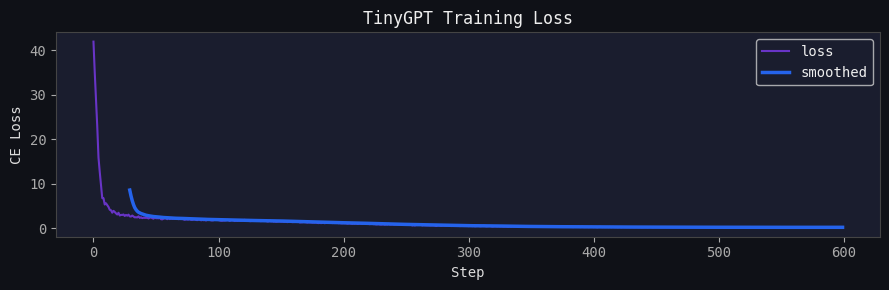

In [4]:
data    = torch.tensor(encode(corpus), dtype=torch.long)
SEQ_LEN = 32
BATCH   = 16

def get_batch(data, seq_len=SEQ_LEN, batch=BATCH):
    idx = torch.randint(len(data)-seq_len, (batch,))
    x   = torch.stack([data[i:i+seq_len]     for i in idx])
    y   = torch.stack([data[i+1:i+seq_len+1] for i in idx])
    return x, y

opt   = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=600)
losses = []

model.train()
for step in range(600):
    x, y   = get_batch(data)
    logits = model(x)
    loss   = F.cross_entropy(logits.view(-1,V), y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.4f}")

model.eval()
print(f"\nFinal loss: {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(losses, color=PALETTE[0], lw=1.5, alpha=0.8, label="loss")
smooth = np.convolve(losses, np.ones(30)/30, mode='valid')
ax.plot(range(29, len(losses)), smooth, color=PALETTE[1], lw=2.5, label="smoothed")
ax.set(xlabel="Step", ylabel="CE Loss", title="TinyGPT Training Loss")
ax.legend(); plt.tight_layout(); plt.show()


## 5 · Strategy 1 — Greedy Decoding

**Algorithm:** At every step, pick the token with the **highest logit** (argmax).

$$\hat{w}_t = \arg\max_{w} P(w \mid w_{<t})$$

- ✅ Deterministic, fast
- ❌ Gets stuck in repetition loops, misses the globally best sequence


In [5]:
def greedy_decode(model, prompt, max_new=40):
    ids = torch.tensor([BOS] + encode(prompt), dtype=torch.long).unsqueeze(0)
    generated = []
    for _ in range(max_new):
        logits  = model.logits_next(ids)
        next_id = logits.argmax(dim=-1)
        generated.append(next_id.item())
        if next_id.item() == EOS: break
        ids = torch.cat([ids, next_id.unsqueeze(0)], dim=1)
    return decode(generated)

prompt = "the cat"
out = greedy_decode(model, prompt, max_new=60)
print(f"Prompt  : {prompt!r}")
print(f"Greedy  : {out!r}")

print("\n[Determinism check — 5 runs]")
for i in range(5):
    print(f"  run {i+1}: {greedy_decode(model, prompt, 30)!r}")


Prompt  : 'the cat'
Greedy  : ' in the sun. the he set. bstnovest d. m o hog titig bro g g '

[Determinism check — 5 runs]
  run 1: ' in the sun. the he set. bstno'
  run 2: ' in the sun. the he set. bstno'
  run 3: ' in the sun. the he set. bstno'
  run 4: ' in the sun. the he set. bstno'
  run 5: ' in the sun. the he set. bstno'


## 6 · Strategy 2 — Beam Search

**Algorithm:** Maintain **B beams** (partial sequences). At each step, expand every beam by every vocabulary token, keep the top-B by cumulative log-prob.

$$\text{score}(w_{1:t}) = \sum_{i=1}^{t} \log P(w_i \mid w_{<i})$$

- Finds a better sequence than greedy
- Still deterministic; wider beams → diminishing returns; expensive


In [6]:
def beam_search(model, prompt, max_new=40, beam_width=4, length_penalty=0.7):
    init_ids = [BOS] + encode(prompt)
    beams    = [(0.0, init_ids)]
    finished = []

    for step in range(max_new):
        candidates = []
        for log_prob, ids in beams:
            idx    = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
            logits = model.logits_next(idx)[0]
            log_p  = F.log_softmax(logits, dim=-1)
            topk_lp, topk_ids = torch.topk(log_p, beam_width)
            for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                candidates.append((log_prob + lp, ids + [tid]))

        candidates.sort(
            key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
        beams = []
        for score, ids in candidates[:beam_width * 2]:
            if ids[-1] == EOS:
                finished.append((score / (len(ids)**length_penalty), ids))
            else:
                beams.append((score, ids))
            if len(beams) == beam_width: break
        if not beams: break

    for score, ids in beams:
        finished.append((score / (len(ids)**length_penalty), ids))
    finished.sort(reverse=True)

    results = []
    for score, ids in finished[:beam_width]:
        text = decode([t for t in ids if t not in (PAD,BOS,EOS)])
        results.append((score, text))
    return results

prompt  = "the cat"
results = beam_search(model, prompt, max_new=50, beam_width=4)
print(f"Prompt : {prompt!r}\n")
for rank, (score, text) in enumerate(results, 1):
    print(f"  Beam {rank} [score={score:.3f}]: {text!r}")


Prompt : 'the cat'

  Beam 1 [score=-0.366]: 'the cat and the dog play in the by sumpsund. '
  Beam 2 [score=-0.371]: 'the cat and the dog play in the by sumpsund. f o og bea l'
  Beam 3 [score=-0.376]: 'the cat and the dog play in the sueresuerog. f o og qui l'
  Beam 4 [score=-0.397]: 'the cat and the dog play in the sueresuerog. f o og quers'


## 7 · Strategy 3 — Temperature Sampling

Scale logits by **T** before softmax:

$$P_T(w) = \frac{\exp(z_w / T)}{\sum_{v} \exp(z_v / T)}$$

- **T → 0** → greedy (peaky distribution)
- **T = 1** → unmodified model distribution
- **T → ∞** → uniform (maximum entropy)


In [7]:
def temperature_sample(model, prompt, max_new=50, temperature=1.0):
    ids = torch.tensor([BOS] + encode(prompt), dtype=torch.long).unsqueeze(0)
    generated = []
    for _ in range(max_new):
        logits  = model.logits_next(ids)[0]
        logits  = logits / max(temperature, 1e-10)
        probs   = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        generated.append(next_id)
        if next_id == EOS: break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)
    return decode(generated)

prompt = "the"
temps  = [0.1, 0.5, 1.0, 1.5, 2.0]
print(f"Prompt: {prompt!r}\n")
for T in temps:
    outs = [temperature_sample(model, prompt, 40, T) for _ in range(3)]
    print(f"  T={T:.1f}: {outs[0]!r}")
    print(f"        {outs[1]!r}")
    print(f"        {outs[2]!r}")
    print()


Prompt: 'the'

  T=0.1: ' sea. the cat in the hat. to bes bestt b'
        ' sea. the cat in the hat. to bes bestt b'
        ' sea. the cat in the hat. to bes bestt b'

  T=0.5: ' sea. the cat in the hat. to bes bestt b'
        ' sea. the cat in the hat. to bes bestt b'
        ' sea. the cat in the hat. to bes bestt b'

  T=1.0: ' tog play in. the dog fog logog. tha the'
        ' te that gold leay in the sunolers lo fo'
        ' sea. the cat in the hat. to bers sat ow'

  T=1.5: ' tog to raw thick. tox ox tharan jumathe'
        ' fog. a big cat satthe don and jsumps th'
        ' sun. the seto bio <EOS>'

  T=2.0: ' sun the fook. the be sat seaog. beao ol'
        ' is the questhe be old zog. tin. jvers r'
        ' frew thaat old man juman. the juers the'



## 8 · Strategy 4 — Top-K Sampling

Keep only the **K most probable** tokens; set all others to −∞; then sample.

$$P_{\text{top-k}}(w) \propto P(w) \cdot \mathbf{1}[P(w) \in \text{top-}K]$$

- **K=1** → greedy
- **K=V** → plain temperature sampling
- Typical values: 20–100


In [8]:
def topk_sample(model, prompt, max_new=50, k=10, temperature=1.0):
    ids = torch.tensor([BOS] + encode(prompt), dtype=torch.long).unsqueeze(0)
    generated = []
    for _ in range(max_new):
        logits = model.logits_next(ids)[0]
        logits = logits / max(temperature, 1e-10)
        topk_vals, _ = torch.topk(logits, min(k, logits.size(-1)))
        threshold     = topk_vals[-1]
        logits        = logits.masked_fill(logits < threshold, float('-inf'))
        probs         = F.softmax(logits, dim=-1)
        next_id       = torch.multinomial(probs, 1).item()
        generated.append(next_id)
        if next_id == EOS: break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)
    return decode(generated)

prompt = "the"
print(f"Prompt: {prompt!r}\n")
for k in [1, 5, 20, 50]:
    outs = [topk_sample(model, prompt, 40, k=k) for _ in range(3)]
    print(f"  K={k:>3}: {outs[0]!r}")
    print(f"         {outs[1]!r}")
    print(f"         {outs[2]!r}")
    print()


Prompt: 'the'

  K=  1: ' sea. the cat in the hat. to bes bestt b'
         ' sea. the cat in the hat. to bes bestt b'
         ' sea. the cat in the hat. to bes bestt b'

  K=  5: ' fog. a big cat sat by the old jsumps og'
         ' tog gorew thick. the old man.k. japlo d'
         ' sea. the cat in the questhe bes best. b'

  K= 20: ' tog quers biown fox jumps oveatld<PAD><PAD>e ju'
         ' sea. the cat in the hat. to bes besto b'
         ' sun set and the fog og grewnbay juew jk'

  K= 50: ' question. all that glitters ck. js og g'
         ' sun set and the fog grew thickrokrae fr'
         ' sea. the cat in the hat. to berstoto ol'



## 9 · Strategy 5 — Top-P (Nucleus) Sampling

Sort tokens by probability descending; keep the **smallest set** whose cumulative probability ≥ p.

$$\mathcal{V}_p = \arg\min_{\mathcal{V}'} \left\{ |\mathcal{V}'| \;:\; \sum_{w \in \mathcal{V}'} P(w) \geq p \right\}$$

- **p=1.0** → all tokens
- **p=0.9** → typical sweet-spot
- Adapts nucleus size to distribution sharpness


In [9]:
def nucleus_sample(model, prompt, max_new=50, p=0.9, temperature=1.0):
    ids = torch.tensor([BOS] + encode(prompt), dtype=torch.long).unsqueeze(0)
    generated = []
    for _ in range(max_new):
        logits = model.logits_next(ids)[0]
        logits = logits / max(temperature, 1e-10)
        probs  = F.softmax(logits, dim=-1)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumprobs = torch.cumsum(sorted_probs, dim=-1)
        remove   = cumprobs - sorted_probs > p
        sorted_probs[remove] = 0.0
        sorted_probs /= sorted_probs.sum()
        sample_idx = torch.multinomial(sorted_probs, 1)
        next_id    = sorted_idx[sample_idx].item()
        generated.append(next_id)
        if next_id == EOS: break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)
    return decode(generated)

prompt = "the"
print(f"Prompt: {prompt!r}\n")
for p in [0.5, 0.8, 0.9, 0.95, 1.0]:
    outs = [nucleus_sample(model, prompt, 40, p=p) for _ in range(3)]
    print(f"  p={p:.2f}: {outs[0]!r}")
    print(f"          {outs[1]!r}")
    print(f"          {outs[2]!r}")
    print()


Prompt: 'the'

  p=0.50: ' sea. the cat in the hat. to bes bestt b'
          ' sea. the cat in the hat. to bes bestt b'
          ' sea. the cat in the hat. to bes bestt b'

  p=0.80: ' sea. the cat in the hat. to bes bestt b'
          ' tog play in. the dog log. the jalaps fr'
          ' set atn and the fog grew thickeas jeakr'

  p=0.90: ' set and the fog grew thick. ok. jumpt o'
          ' sea. the cat in the hat. to berstolo ow'
          ' sea. that is the question. iott bes f h'

  p=0.95: ' tog question. all that glittetty suik l'
          ' tog plitters is not gold. the brrolox t'
          ' sun. the sun sun setion alllealplestogl'

  p=1.00: ' sea. the cat in the hat. to bes bestt b'
          ' tog. to or not to be that iset tew ick.'
          ' tog play in the sun. the sunololdofox b'



## 10 · Visualising the Distribution Transformations

See exactly how each strategy reshapes the token probability distribution.


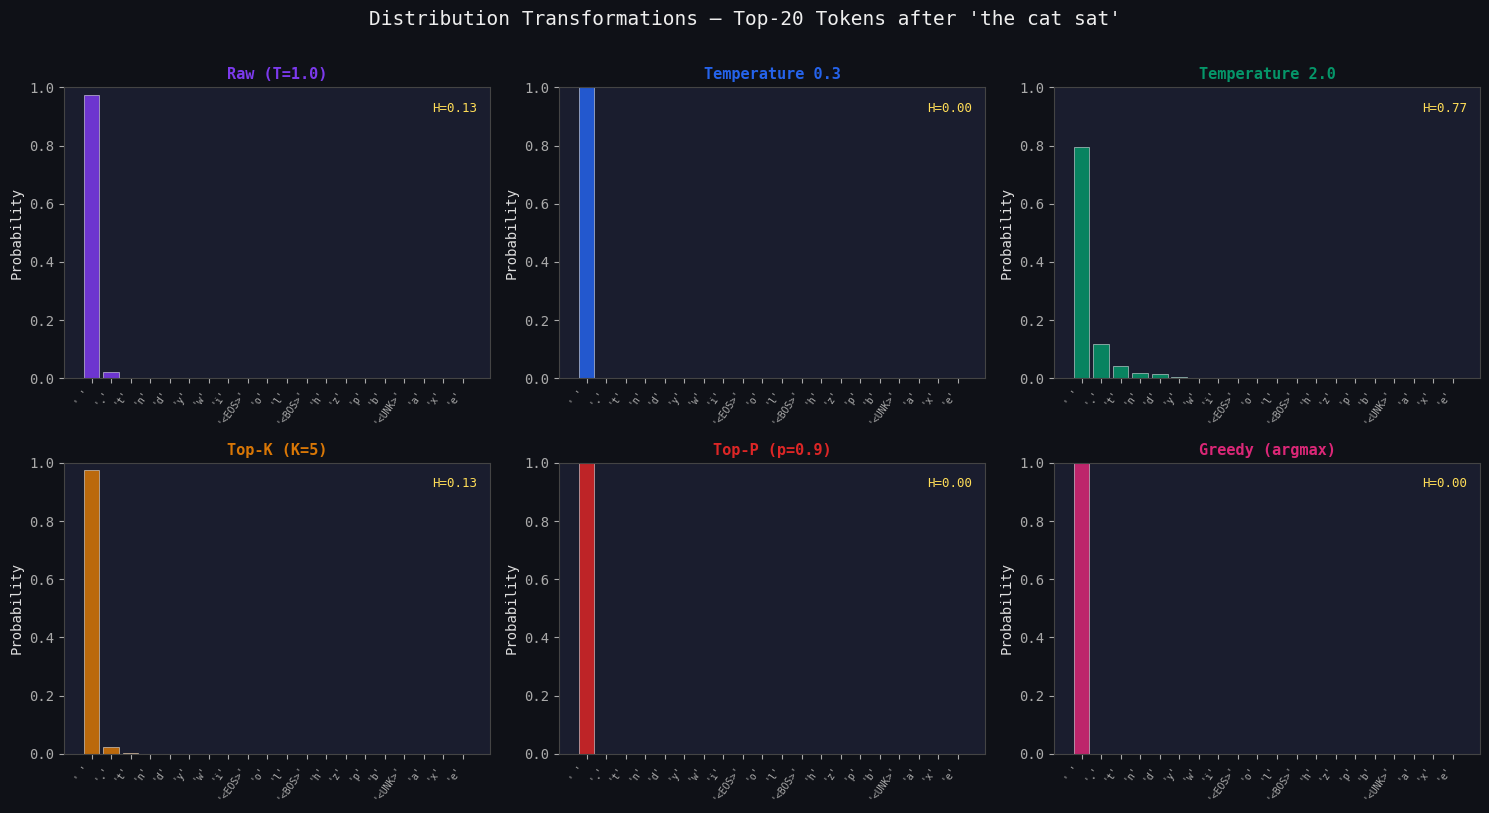

H = Shannon entropy of the top-20 distribution (higher = more diverse)


In [10]:
def get_probs_for(model, prompt):
    ids    = torch.tensor([BOS]+encode(prompt), dtype=torch.long).unsqueeze(0)
    logits = model.logits_next(ids)[0].detach()
    return logits, F.softmax(logits, dim=-1)

logits, raw_probs = get_probs_for(model, "the cat sat")
topv, topi = torch.topk(raw_probs, 20)
labels = [repr(itos[i.item()]) for i in topi]

def apply_topk(logits, k=5):
    l = logits.clone()
    topk_vals, _ = torch.topk(l, k)
    l[l < topk_vals[-1]] = float('-inf')
    return F.softmax(l, dim=-1)

def apply_topp(logits, p=0.9):
    probs   = F.softmax(logits, dim=-1)
    sp, si  = torch.sort(probs, descending=True)
    cum     = torch.cumsum(sp, dim=-1)
    remove  = cum - sp > p
    sp[remove] = 0.0; sp /= sp.sum()
    out = torch.zeros_like(probs); out[si] = sp
    return out

computed = [
    F.softmax(logits, dim=-1),
    F.softmax(logits/0.3, dim=-1),
    F.softmax(logits/2.0, dim=-1),
    apply_topk(logits, k=5),
    apply_topp(logits, p=0.9),
    None,
]
titles = ["Raw (T=1.0)","Temperature 0.3","Temperature 2.0",
          "Top-K (K=5)","Top-P (p=0.9)","Greedy (argmax)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution Transformations — Top-20 Tokens after 'the cat sat'",
             fontsize=14, y=1.01)

for ax, title, probs_full, col in zip(axes.flat, titles, computed, PALETTE):
    if probs_full is None:
        p_show = np.zeros(20); p_show[0] = 1.0
    else:
        topv2, _ = torch.topk(probs_full, 20)
        p_show = topv2.numpy()
    ax.bar(range(20), p_show, color=col, alpha=0.85, edgecolor='white', lw=0.4)
    ax.set_xticks(range(20))
    ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
    ax.set_title(title, color=col, fontsize=11, fontweight='bold')
    ax.set_ylabel("Probability"); ax.set_ylim(0, 1.0)
    p_np = p_show + 1e-12
    ent  = -np.sum(p_np * np.log(p_np))
    ax.text(0.97, 0.95, f"H={ent:.2f}", transform=ax.transAxes,
            ha='right', va='top', color='#ffdd57', fontsize=9)

plt.tight_layout(); plt.show()
print("H = Shannon entropy of the top-20 distribution (higher = more diverse)")


## 11 · Quantifying Output Diversity

Run each strategy **50 times**, measure:
- **Unique outputs** (exact match)
- **Type-Token Ratio (TTR)** — vocabulary richness
- **Mean Unigram Entropy** — average surprise per token


In [11]:
N_SAMPLES = 50
MAX_NEW   = 40
PROMPT    = "the"

strategies = {
    "Greedy":      lambda: greedy_decode(model, PROMPT, MAX_NEW),
    "Beam (w=4)":  lambda: beam_search(model, PROMPT, MAX_NEW, beam_width=4)[0][1],
    "Temp 0.3":    lambda: temperature_sample(model, PROMPT, MAX_NEW, 0.3),
    "Temp 1.0":    lambda: temperature_sample(model, PROMPT, MAX_NEW, 1.0),
    "Temp 1.5":    lambda: temperature_sample(model, PROMPT, MAX_NEW, 1.5),
    "Top-K 5":     lambda: topk_sample(model, PROMPT, MAX_NEW, k=5),
    "Top-K 20":    lambda: topk_sample(model, PROMPT, MAX_NEW, k=20),
    "Top-P 0.8":   lambda: nucleus_sample(model, PROMPT, MAX_NEW, p=0.8),
    "Top-P 0.95":  lambda: nucleus_sample(model, PROMPT, MAX_NEW, p=0.95),
}

def ttr(text):
    tokens = list(text); return len(set(tokens))/(len(tokens)+1e-9)

def mean_entropy(texts):
    all_chars = "".join(texts)
    cnt = Counter(all_chars); total = len(all_chars)
    probs = np.array([v/total for v in cnt.values()])
    return -np.sum(probs*np.log(probs+1e-12))

results = {}
for name, fn in strategies.items():
    outs    = [fn() for _ in range(N_SAMPLES)]
    unique  = len(set(outs))
    avg_ttr = np.mean([ttr(o) for o in outs])
    ent     = mean_entropy(outs)
    results[name] = dict(unique=unique, ttr=avg_ttr, entropy=ent)
    print(f"{name:14s}  unique={unique:3d}/{N_SAMPLES}  TTR={avg_ttr:.3f}  H={ent:.3f}")


Greedy          unique=  1/50  TTR=0.300  H=2.207
Beam (w=4)      unique=  1/50  TTR=0.279  H=2.198
Temp 0.3        unique= 12/50  TTR=0.333  H=2.435
Temp 1.0        unique= 48/50  TTR=0.406  H=2.813
Temp 1.5        unique= 50/50  TTR=0.416  H=2.977
Top-K 5         unique= 47/50  TTR=0.380  H=2.801
Top-K 20        unique= 49/50  TTR=0.413  H=2.869
Top-P 0.8       unique= 38/50  TTR=0.385  H=2.713
Top-P 0.95      unique= 48/50  TTR=0.398  H=2.780


## 12 · Diversity Dashboard

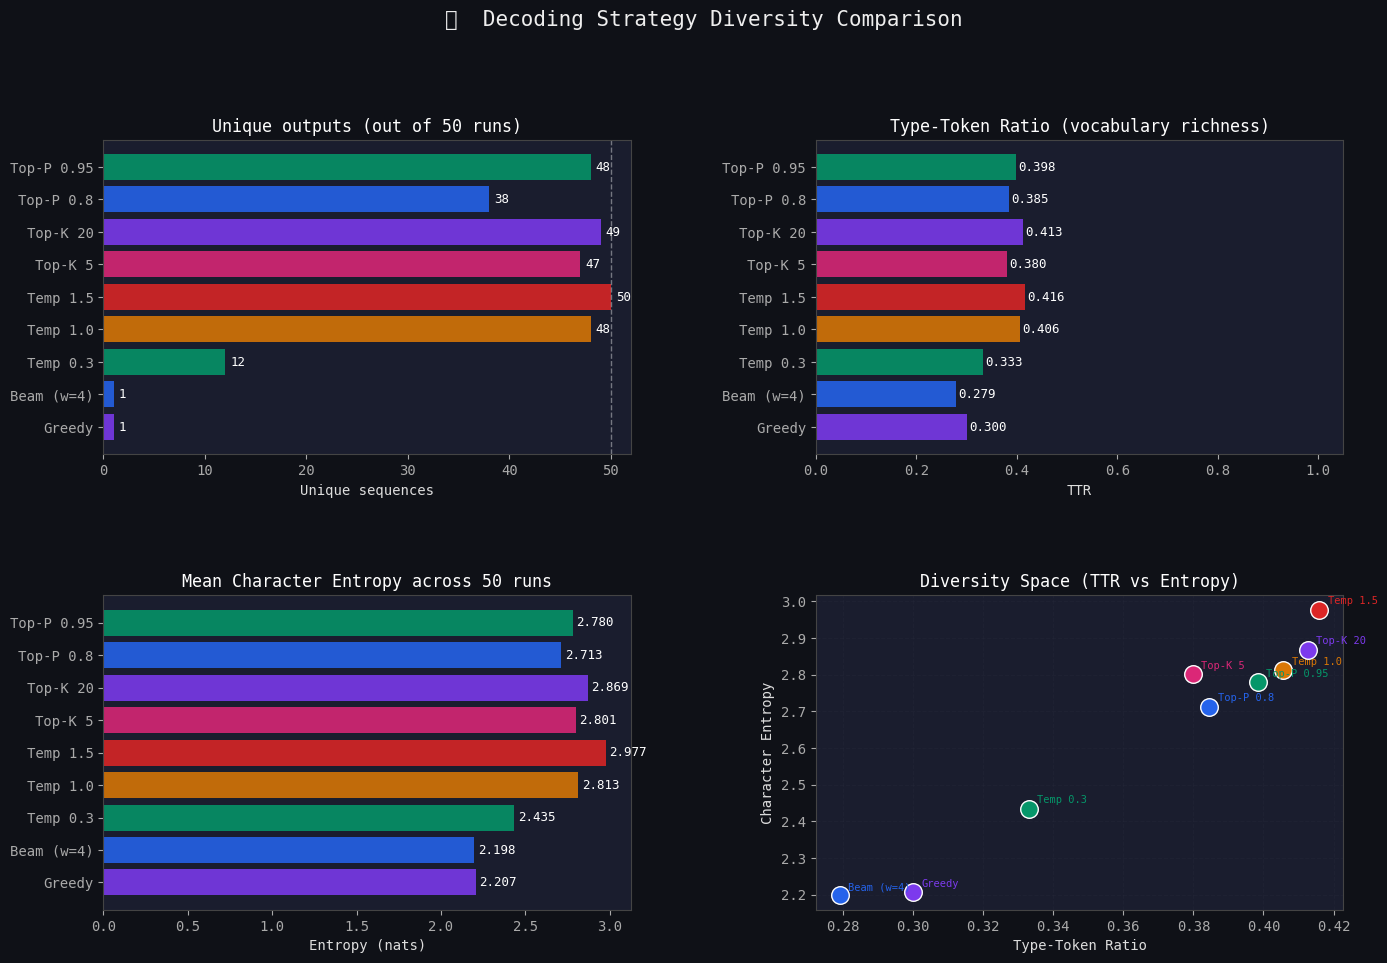

In [12]:
names   = list(results.keys())
uniques = [results[n]['unique']  for n in names]
ttrs    = [results[n]['ttr']     for n in names]
ents    = [results[n]['entropy'] for n in names]
strat_colors = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(names, uniques, color=strat_colors, alpha=0.88)
ax1.set_xlim(0, N_SAMPLES+2)
ax1.axvline(N_SAMPLES, color='white', ls='--', alpha=0.4, lw=1)
ax1.set_title(f"Unique outputs (out of {N_SAMPLES} runs)", color='white')
ax1.set_xlabel("Unique sequences")
for bar, v in zip(bars, uniques):
    ax1.text(v+0.5, bar.get_y()+bar.get_height()/2, str(v),
             va='center', color='white', fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.barh(names, ttrs, color=strat_colors, alpha=0.88)
ax2.set_xlim(0, 1.05)
ax2.set_title("Type-Token Ratio (vocabulary richness)", color='white')
ax2.set_xlabel("TTR")
for bar, v in zip(bars, ttrs):
    ax2.text(v+0.005, bar.get_y()+bar.get_height()/2, f"{v:.3f}",
             va='center', color='white', fontsize=9)

ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.barh(names, ents, color=strat_colors, alpha=0.88)
ax3.set_title("Mean Character Entropy across 50 runs", color='white')
ax3.set_xlabel("Entropy (nats)")
for bar, v in zip(bars, ents):
    ax3.text(v+0.02, bar.get_y()+bar.get_height()/2, f"{v:.3f}",
             va='center', color='white', fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
for i, (n, col) in enumerate(zip(names, strat_colors)):
    ax4.scatter(ttrs[i], ents[i], color=col, s=160, zorder=3, edgecolors='white', lw=1)
    ax4.annotate(n, (ttrs[i], ents[i]),
                 textcoords='offset points', xytext=(6, 4),
                 color=col, fontsize=7.5)
ax4.set_xlabel("Type-Token Ratio"); ax4.set_ylabel("Character Entropy")
ax4.set_title("Diversity Space (TTR vs Entropy)", color='white')
ax4.grid(True, alpha=0.3)

fig.suptitle("🎲  Decoding Strategy Diversity Comparison", fontsize=15, y=1.01)
plt.show()


## 13 · Temperature Sweep — Continuous Diversity Curve

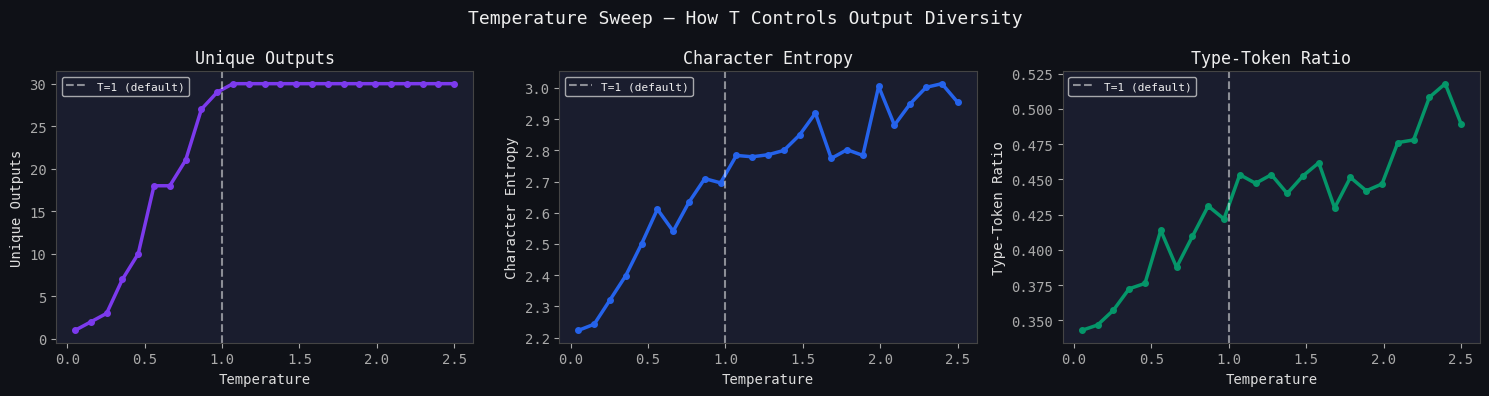

In [13]:
temps   = np.linspace(0.05, 2.5, 25)
n_runs  = 30
uniq_t, ent_t, ttr_t = [], [], []

for T in temps:
    outs = [temperature_sample(model, "the", 35, float(T)) for _ in range(n_runs)]
    uniq_t.append(len(set(outs)))
    ent_t.append(mean_entropy(outs))
    ttr_t.append(np.mean([ttr(o) for o in outs]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Temperature Sweep — How T Controls Output Diversity", fontsize=13)
for ax, vals, ylabel, col in zip(
        axes, [uniq_t, ent_t, ttr_t],
        ["Unique Outputs","Character Entropy","Type-Token Ratio"], PALETTE):
    ax.plot(temps, vals, color=col, lw=2.5, marker='o', ms=4)
    ax.axvline(1.0, color='white', ls='--', alpha=0.5, lw=1.5, label="T=1 (default)")
    ax.set_xlabel("Temperature"); ax.set_ylabel(ylabel); ax.set_title(ylabel)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 14 · Top-K Sweep

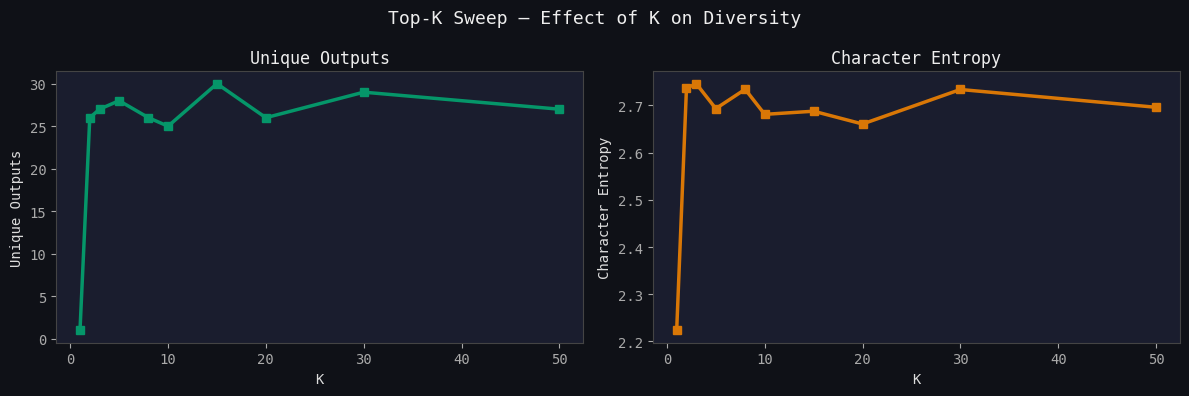

In [14]:
ks      = [1,2,3,5,8,10,15,20,30,50]
n_runs  = 30
uniq_k, ent_k = [], []
for k in ks:
    outs = [topk_sample(model, "the", 35, k=k) for _ in range(n_runs)]
    uniq_k.append(len(set(outs))); ent_k.append(mean_entropy(outs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Top-K Sweep — Effect of K on Diversity", fontsize=13)
for ax, vals, lbl, col in zip([ax1,ax2],[uniq_k,ent_k],
                               ["Unique Outputs","Character Entropy"],PALETTE[2:]):
    ax.plot(ks, vals, color=col, lw=2.5, marker='s', ms=6)
    ax.set_xlabel("K"); ax.set_ylabel(lbl); ax.set_title(lbl)
plt.tight_layout(); plt.show()


## 15 · Top-P (Nucleus) Sweep

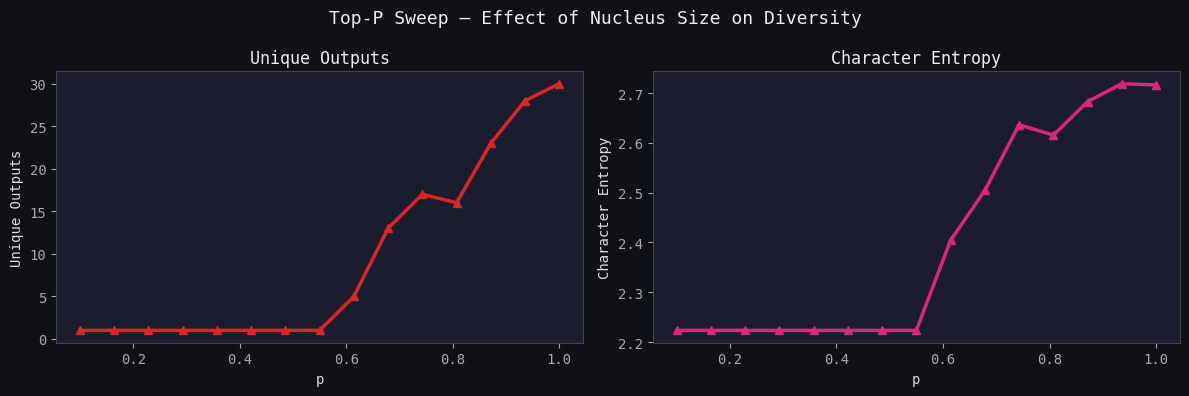

In [15]:
ps      = np.linspace(0.1, 1.0, 15)
n_runs  = 30
uniq_p, ent_p = [], []
for p in ps:
    outs = [nucleus_sample(model, "the", 35, p=float(p)) for _ in range(n_runs)]
    uniq_p.append(len(set(outs))); ent_p.append(mean_entropy(outs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Top-P Sweep — Effect of Nucleus Size on Diversity", fontsize=13)
for ax, vals, lbl, col in zip([ax1,ax2],[uniq_p,ent_p],
                               ["Unique Outputs","Character Entropy"],PALETTE[4:]):
    ax.plot(ps, vals, color=col, lw=2.5, marker='^', ms=6)
    ax.set_xlabel("p"); ax.set_ylabel(lbl); ax.set_title(lbl)
plt.tight_layout(); plt.show()


## 16 · Token Probability Heatmap

Visualise how the probability mass moves across tokens at each decoding step.


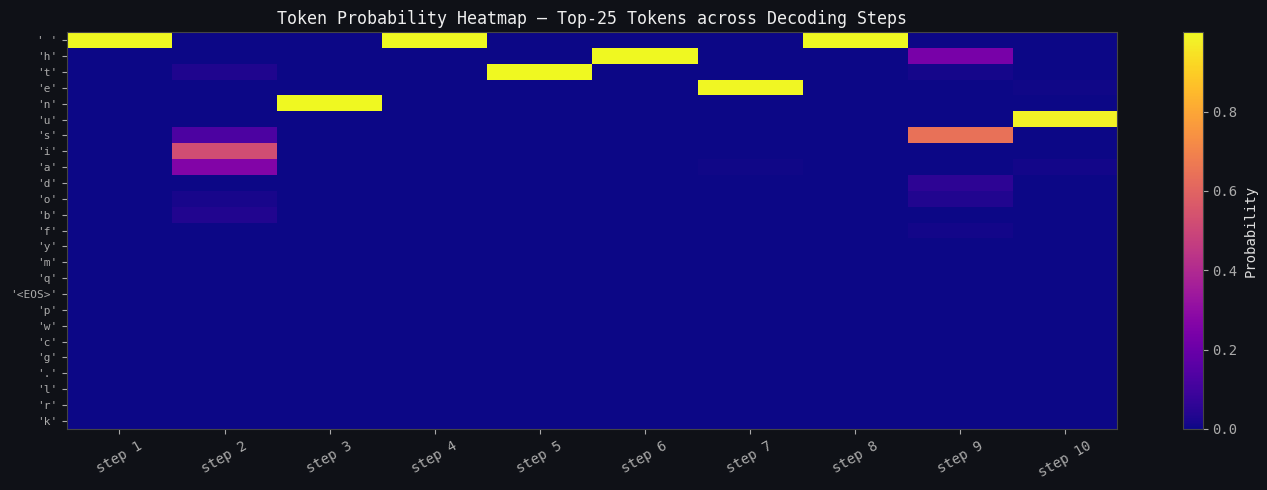

In [16]:
def beam_step_probs(model, prompt, steps=10):
    ids   = [BOS] + encode(prompt)
    probs_history = []
    for _ in range(steps):
        idx    = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
        logits = model.logits_next(idx)[0].detach()
        probs  = F.softmax(logits, dim=-1).numpy()
        probs_history.append(probs)
        ids.append(int(np.argmax(probs)))
    return np.stack(probs_history)

steps = 10
ph    = beam_step_probs(model, "the cat", steps=steps)
top_chars = np.argsort(-ph.mean(0))[:25]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(ph[:, top_chars].T, aspect='auto', cmap='plasma',
               vmin=0, vmax=ph[:, top_chars].max())
ax.set_yticks(range(25))
ax.set_yticklabels([repr(itos[i]) for i in top_chars], fontsize=8)
ax.set_xticks(range(steps))
ax.set_xticklabels([f"step {i+1}" for i in range(steps)], rotation=30)
ax.set_title("Token Probability Heatmap — Top-25 Tokens across Decoding Steps", fontsize=12)
plt.colorbar(im, ax=ax, label="Probability")
plt.tight_layout(); plt.show()


## 17 · Side-by-Side Generation Gallery

In [17]:
torch.manual_seed(99)
prompts = ["the cat", "a big", "the fog"]

print("=" * 65)
for prompt in prompts:
    print(f"\nPROMPT: {prompt!r}")
    print("-" * 65)
    print(f"  Greedy    : {greedy_decode(model, prompt, 50)!r}")
    print(f"  Beam(w=4) : {beam_search(model, prompt, 50, 4)[0][1]!r}")
    print(f"  Temp 0.5  : {temperature_sample(model, prompt, 50, 0.5)!r}")
    print(f"  Temp 1.0  : {temperature_sample(model, prompt, 50, 1.0)!r}")
    print(f"  Top-K 10  : {topk_sample(model, prompt, 50, k=10)!r}")
    print(f"  Top-P 0.9 : {nucleus_sample(model, prompt, 50, p=0.9)!r}")
print("=" * 65)



PROMPT: 'the cat'
-----------------------------------------------------------------
  Greedy    : ' in the sun. the he set. bstnovest d. m o hog titi'
  Beam(w=4) : 'the cat and the dog play in the by sumpsund. '
  Temp 0.5  : ' in the sun. the he set. bstnover f. d d og dog th'
  Temp 1.0  : ' in the sun. the he set. bstnovest d. t t hog mayy'
  Top-K 10  : ' in the sun. the hiow thallick. ok. ox t he by by '
  Top-P 0.9 : ' in the sun. the he set. at. beatt d. d o h. qumth'

PROMPT: 'a big'
-----------------------------------------------------------------
  Greedy    : ' cat sat by the old log. the lpld<PAD><PAD><PAD>og. ld og. by '
  Beam(w=4) : 'a big cat sat by the old log. the lpldean t therolay'
  Temp 0.5  : ' cat the lot glat by that ogld s s t d d d he dogr'
  Temp 1.0  : '. the cat sat by the olog. s tt suererat d og onde'
  Top-K 10  : ' cat the to by that old logogog. jan ld pldog. nnd'
  Top-P 0.9 : ' cat sat by the old log. the lpld<PAD><PAD><PAD>og. ld he ogla'

PROMPT

## 18 · Combined Strategy — Top-P + Temperature (Production Best Practice)

Real LLMs (GPT-4, Claude) typically combine **Top-P + Temperature** (and sometimes Top-K):


In [18]:
def combined_sample(model, prompt, max_new=50, temperature=0.9, top_p=0.92, top_k=50):
    ids = torch.tensor([BOS]+encode(prompt), dtype=torch.long).unsqueeze(0)
    generated = []
    for _ in range(max_new):
        logits = model.logits_next(ids)[0]
        # 1. temperature
        logits = logits / max(temperature, 1e-10)
        # 2. top-k
        if top_k > 0:
            topk_v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < topk_v[-1]] = float('-inf')
        # 3. top-p
        probs  = F.softmax(logits, dim=-1)
        sp, si = torch.sort(probs, descending=True)
        cum    = torch.cumsum(sp, dim=-1)
        remove = cum - sp > top_p
        sp[remove] = 0.0; sp /= sp.sum()
        out = torch.zeros_like(probs); out[si] = sp; probs = out
        # 4. sample
        next_id = torch.multinomial(probs, 1).item()
        generated.append(next_id)
        if next_id == EOS: break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)
    return decode(generated)

prompt = "the cat sat"
print(f"Combined (T=0.9, p=0.92, k=50) — 5 samples from {prompt!r}:")
for i in range(5):
    print(f"  {i+1}: {combined_sample(model, prompt)!r}")


Combined (T=0.9, p=0.92, k=50) — 5 samples from 'the cat sat':
  1: ' on. the dog play dogog. ldpld sn thy hery m lpt t'
  2: ' on. the dog platherawn. jun f g f ox hed thee g g'
  3: ' on. the dog play dogog teanog the d og d thee o d'
  4: ' on. the dog play dogog teanog the d og d thee d d'
  5: ' in. the hat hat old gldold tofrs d t ldogla g. th'


## 19 · Summary Cheat-Sheet & When to Use What

| Strategy | Deterministic | Diversity | Speed | Best For |
|---|:---:|:---:|:---:|---|
| **Greedy** | ✅ | ❌ | ⚡⚡⚡ | Factual QA, translation |
| **Beam Search** | ✅ | 🔸 | ⚡ | Machine translation, summarisation |
| **Temperature** | ❌ | 🔥 tunable | ⚡⚡ | Creative writing (T≈0.7–1.2) |
| **Top-K** | ❌ | 🔶 | ⚡⚡ | Chatbots (K≈20–50) |
| **Top-P** | ❌ | 🔷 adaptive | ⚡⚡ | Most open-ended tasks (p≈0.9) |
| **Combined** | ❌ | 🎯 | ⚡⚡ | **Production LLMs** |

### Key Intuitions
- **Greedy / Beam**: optimise for probability — safe but boring
- **Temperature**: controls "sharpness" — global rescaling
- **Top-K**: hard cutoff — good vocab control, fixed bucket size
- **Top-P**: adaptive cutoff — handles both peaked & flat distributions gracefully
- **Combine** Top-P + Temperature for best results in practice

### Diversity Ranking (low → high)
`Greedy < Beam < Temp 0.5 < Top-K small < Top-P 0.8 < Top-K large < Temp 1.0 < Top-P 1.0 < Temp >1.5`
